# Equity Return Forecasting: A Machine Learning Approach

goal of the project: to analyze and forecast 6 different stocks, based on historical returns. the goal is to analyze whether the return will go up or down tomorrow. longer horizons, like months or years, are more predicable, as he small upward drift begins to dominate daily noise. However, this reflects general market drift rather than learnable signal from price features. long-horizon forecasting also leaves very few independent obseravtions and typically requires fundamental data, like rates, valuation, macro, earning, rather than techinal features. I will therefore mainly focus on short-horizon direction.

In [60]:
import yfinance as yf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



from seaborn import heatmap, barplot, histplot, boxplot, countplot
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [12]:
tickers = ["AKRBP.OL", "EQNR.OL", "NHY.OL", "NVDA", "PLTR", "NVO"]
data = yf.download(tickers, start="2021-01-01", auto_adjust=True)["Close"]

[*********************100%***********************]  6 of 6 completed


In [4]:
data.head()

Ticker,AKRBP.OL,EQNR.OL,NHY.OL,NVDA,NVO,PLTR
Date,,,,,,
2021-01-04,137.938583,105.348015,28.397556,13.060796,31.630423,23.370001
2021-01-05,140.504868,106.879044,28.296474,13.350874,31.338161,24.600000
2021-01-06,146.343231,109.868141,29.581694,12.563800,30.523388,23.540001
2021-01-07,147.754700,112.747879,30.354267,13.290370,31.037048,25.000000
2021-01-08,148.717010,113.805046,30.318167,13.223389,31.112329,25.200001


In [5]:
data.tail()

Ticker,AKRBP.OL,EQNR.OL,NHY.OL,NVDA,NVO,PLTR
Date,,,,,,
2026-06-03,350.500000,357.200012,118.699997,214.500000,42.000000,142.199997
2026-06-04,347.799988,351.899994,118.099998,218.660004,43.750000,141.699997
2026-06-05,348.500000,354.000000,116.050003,205.100006,42.959999,135.529999
2026-06-08,347.700012,355.799988,114.500000,208.639999,41.020000,136.470001
2026-06-09,344.700012,346.200012,113.099998,206.699997,42.070000,131.850006


In [6]:
data.head()

Ticker,AKRBP.OL,EQNR.OL,NHY.OL,NVDA,NVO,PLTR
Date,,,,,,
2021-01-04,137.938583,105.348015,28.397556,13.060796,31.630423,23.370001
2021-01-05,140.504868,106.879044,28.296474,13.350874,31.338161,24.600000
2021-01-06,146.343231,109.868141,29.581694,12.563800,30.523388,23.540001
2021-01-07,147.754700,112.747879,30.354267,13.290370,31.037048,25.000000
2021-01-08,148.717010,113.805046,30.318167,13.223389,31.112329,25.200001


array([[<Axes: title={'center': 'AKRBP.OL'}>,
        <Axes: title={'center': 'EQNR.OL'}>],
       [<Axes: title={'center': 'NHY.OL'}>,
        <Axes: title={'center': 'NVDA'}>],
       [<Axes: title={'center': 'NVO'}>,
        <Axes: title={'center': 'PLTR'}>]], dtype=object)

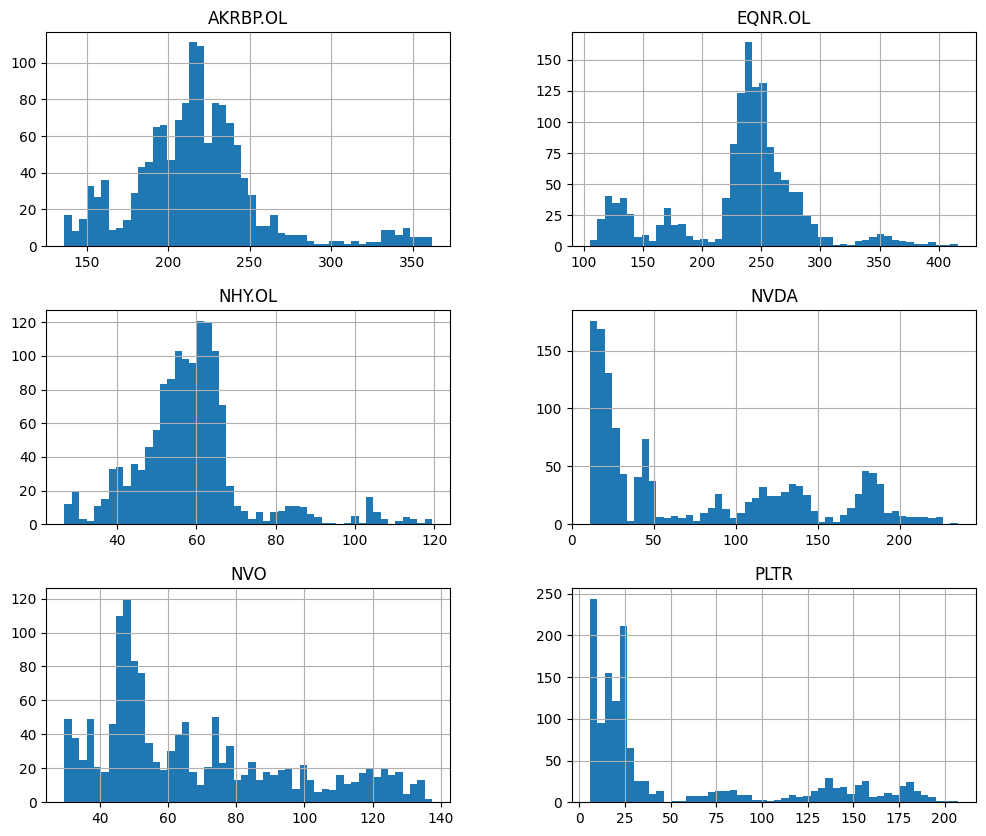

In [9]:
data.hist(bins = 50, figsize=(12,10))

In [7]:
data.describe()

Ticker,AKRBP.OL,EQNR.OL,NHY.OL,NVDA,NVO,PLTR
count,1363.000000,1363.000000,1363.000000,1364.000000,1364.000000,1364.000000
mean,216.967734,232.683129,58.476791,77.201307,67.083647,51.965777
std,39.665678,54.317813,14.150581,64.993388,27.999230,57.035437
min,136.462952,105.348015,26.708000,11.199244,29.695312,6.000000
25%,194.396507,223.791092,51.269457,19.975285,46.557114,14.137500
50%,216.401154,241.072266,57.902477,45.369986,57.095356,23.370001
75%,234.353638,258.524170,63.611126,132.653751,84.769371,79.792501
max,362.000000,416.086975,119.449997,235.465576,137.397034,207.179993


In [8]:
data.value_counts()

AKRBP.OL    EQNR.OL     NHY.OL      NVDA        NVO        PLTR      
136.462952  114.205994  28.578068   14.205926   31.559566  38.169998     1
228.262192  245.528610  60.021095   179.760590  46.558590  160.660004    1
228.226074  273.730713  52.398918   17.038694   47.689037  9.250000      1
228.183472  267.609558  57.121887   48.002678   91.833290  17.870001     1
228.095673  167.908295  45.055775   29.654675   51.218658  26.000000     1
                                                                        ..
202.623337  240.813904  63.331062   108.597801  73.325516  78.050003     1
202.537659  240.744797  59.423306   43.816639   71.502487  16.590000     1
202.505478  178.306824  48.662598   28.297604   52.871460  18.340000     1
202.354111  170.434967  49.638222   19.667452   43.776558  23.170000     1
362.000000  376.000000  104.349998  220.353180  44.279999  135.259995    1
Name: count, Length: 1326, dtype: int64

In [15]:
print(type(data.columns))
print(data.columns[:6].tolist())

<class 'pandas.core.indexes.base.Index'>
['AKRBP.OL', 'EQNR.OL', 'NHY.OL', 'NVDA', 'NVO', 'PLTR']


### Exploring the data

In [ ]:
#exploring NVDA
TICKER = "NVDA"
close = data[TICKER].dropna()

#daily returns
returns = close.pct_change().dropna()

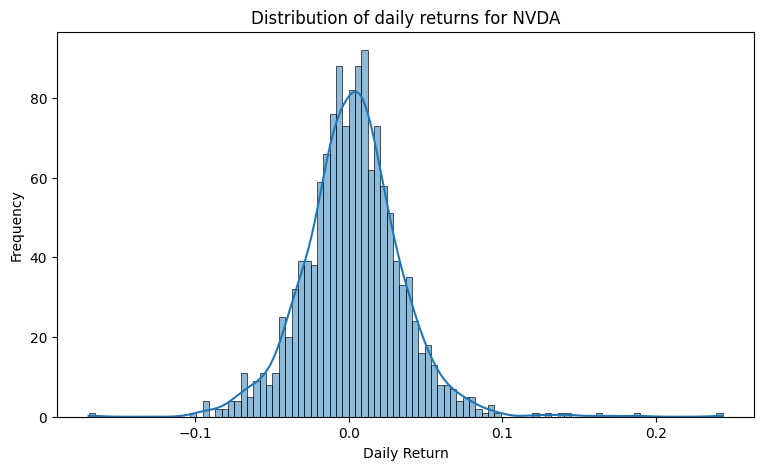

In [17]:
#historgram of returns

plt.figure(figsize=(9,5))
histplot(returns, bins = 100, kde= True)
plt.title(f"Distribution of daily returns for {TICKER}")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

In [19]:
print(returns.describe())
print("\nSkewness:", round(returns.skew(),3))
print("Excess Kurtosis:", round(returns.kurt(),3))

count    1363.000000
mean        0.002542
std         0.032280
min        -0.169682
25%        -0.015708
50%         0.002800
75%         0.020097
max         0.243697
Name: NVDA, dtype: float64

Skewness: 0.506
Excess Kurtosis: 4.524


NVDA Daily Returns is near the center with a positive mean of 0,25%, but the standard deviation is about 13 times larger than the mean daily return, meaning that the directional signal is very small relative to the noise

In [20]:
#exploring EQNR.OL
TICKER = "EQNR.OL"
close = data[TICKER].dropna()

#daily returns
returns = close.pct_change().dropna()

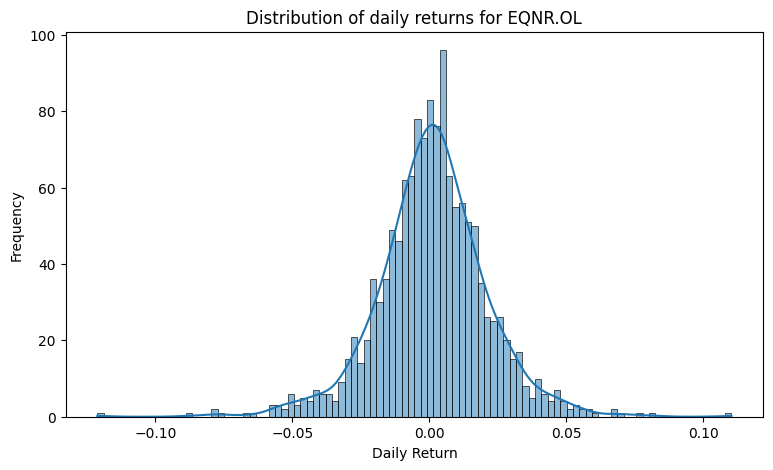

In [21]:
plt.figure(figsize=(9,5))
histplot(returns, bins = 100, kde= True)
plt.title(f"Distribution of daily returns for {TICKER}")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

In [22]:
print(returns.describe())
print("\nSkewness:", round(returns.skew(),3))
print("Excess Kurtosis:", round(returns.kurt(),3))

count    1362.000000
mean        0.001077
std         0.020157
min        -0.121175
25%        -0.009516
50%         0.001294
75%         0.012489
max         0.110306
Name: EQNR.OL, dtype: float64

Skewness: -0.163
Excess Kurtosis: 2.828


Compared to NVDA; EQNR shows a lower volatility, and thinner tails. this makes sense due to the fact that Equinor is a mature energy company, and NIVIDIA a high-growing tech stock.


In [23]:
#exploring AKRBP.OL
TICKER = "AKRBP.OL"
close = data[TICKER].dropna()

#daily returns
returns = close.pct_change().dropna()

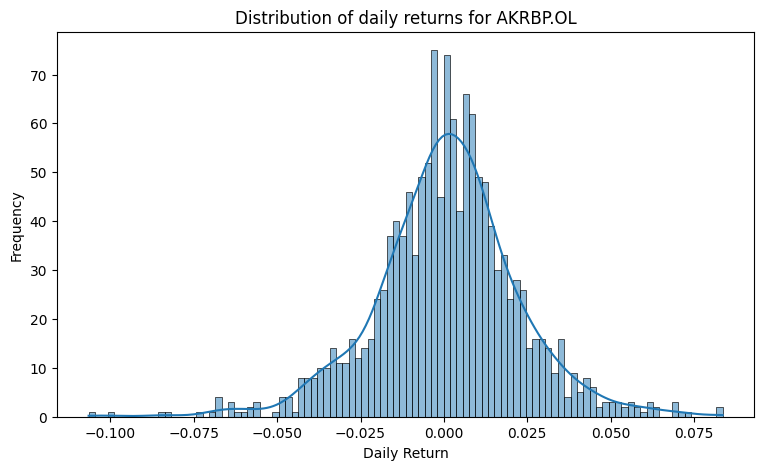

In [24]:
plt.figure(figsize=(9,5))
histplot(returns, bins = 100, kde= True)
plt.title(f"Distribution of daily returns for {TICKER}")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

In [25]:
print(returns.describe())
print("\nSkewness:", round(returns.skew(),3))
print("Excess Kurtosis:", round(returns.kurt(),3))

count    1362.000000
mean        0.000908
std         0.021673
min        -0.106543
25%        -0.011048
50%         0.001225
75%         0.012583
max         0.083619
Name: AKRBP.OL, dtype: float64

Skewness: -0.185
Excess Kurtosis: 1.864


In [26]:
#exploring NHY.OL
TICKER = "NHY.OL"
close = data[TICKER].dropna()

#daily returns
returns = close.pct_change().dropna()

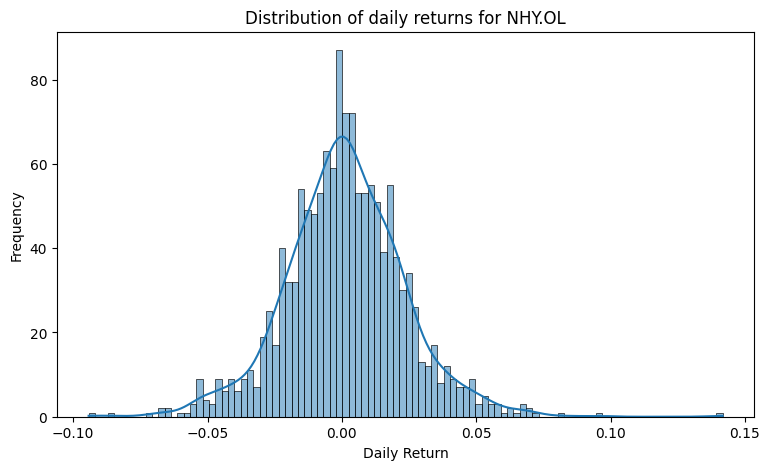

In [ ]:
plt.figure(figsize=(9,5))
histplot(returns, bins = 100, kde= True)
plt.title(f"Distribution of daily returns for {TICKER}")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

In [28]:
print(returns.describe())
print("\nSkewness:", round(returns.skew(),3))
print("Excess Kurtosis:", round(returns.kurt(),3))

count    1362.000000
mean        0.001264
std         0.022329
min        -0.094253
25%        -0.012060
50%         0.000659
75%         0.014387
max         0.141753
Name: NHY.OL, dtype: float64

Skewness: 0.186
Excess Kurtosis: 2.032


In [29]:
#exploring PLTR
TICKER = "PLTR"
close = data[TICKER].dropna()

#daily returns
returns = close.pct_change().dropna()

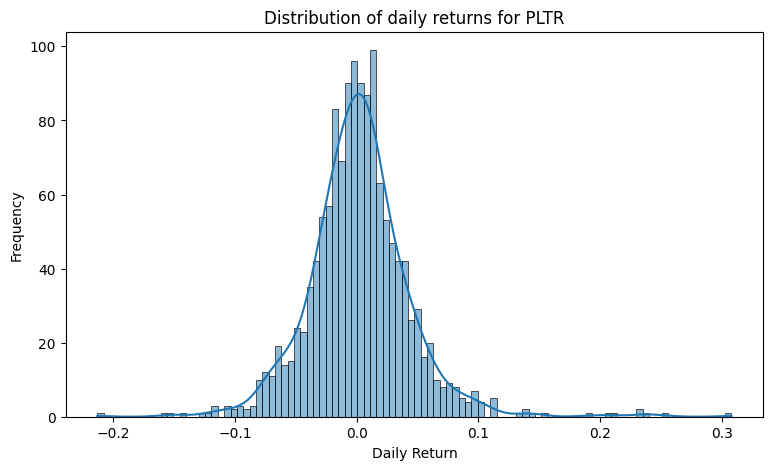

In [30]:
plt.figure(figsize=(9,5))
histplot(returns, bins = 100, kde= True)
plt.title(f"Distribution of daily returns for {TICKER}")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

In [31]:
print(returns.describe())
print("\nSkewness:", round(returns.skew(),3))
print("Excess Kurtosis:", round(returns.kurt(),3))

count    1363.000000
mean        0.002144
std         0.042243
min        -0.213080
25%        -0.020067
50%         0.000888
75%         0.022003
max         0.308014
Name: PLTR, dtype: float64

Skewness: 0.903
Excess Kurtosis: 6.484


In [32]:
#exploring NVO
TICKER = "NVO"
close = data[TICKER].dropna()

#daily returns
returns = close.pct_change().dropna()

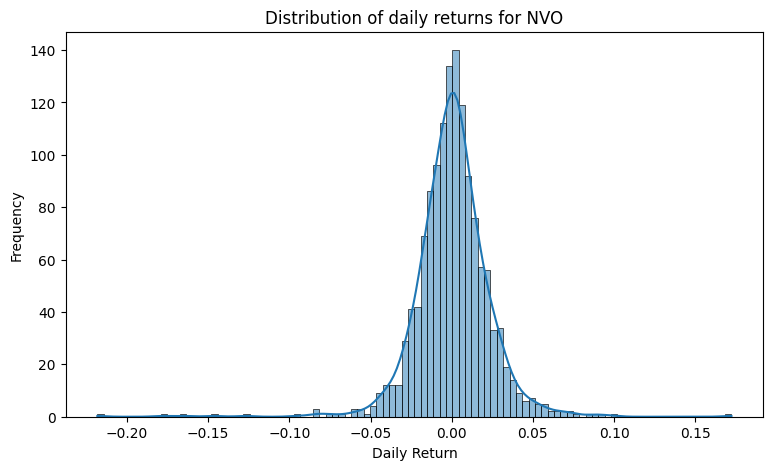

In [33]:
plt.figure(figsize=(9,5))
histplot(returns, bins = 100, kde= True)
plt.title(f"Distribution of daily returns for {TICKER}")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

In [34]:
print(returns.describe())
print("\nSkewness:", round(returns.skew(),3))
print("Excess Kurtosis:", round(returns.kurt(),3))

count    1363.000000
mean        0.000494
std         0.023492
min        -0.218261
25%        -0.011123
50%         0.000566
75%         0.011978
max         0.172348
Name: NVO, dtype: float64

Skewness: -1.029
Excess Kurtosis: 13.905


#### Comments on the histograms and statistical volumes

we can clearly see that the returns cluster by sector, based on the six stocks. the norwegian stocks are the calmest, with a standard deviation at 2%, while the US tech companies are by fare more volatile. 
the Skewness differs due toe the company type. the oil stocks have a mild negative skew, while the tech stocks are positive. 
Novo Nordisk is an outlier, with the excess kurtosis of 13,9, and a strong negativ skew at -1.03. 
all six stocks have the same extreme excess kurtosis relative to a normal distribution, confirming heavy tails as a universal feature of the data.

## Historical Price

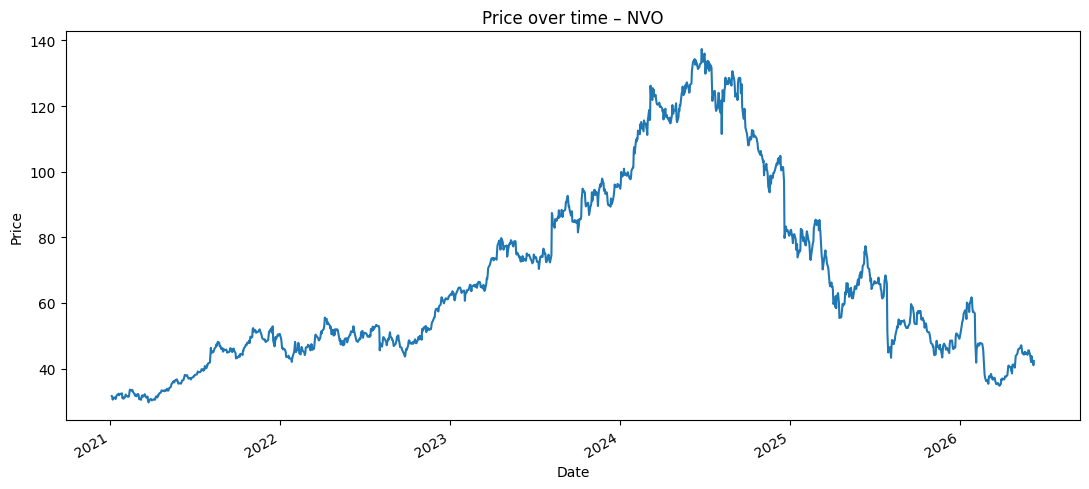

In [35]:
TICKER = "NVO"

plt.figure(figsize=(11, 5))
data[TICKER].dropna().plot()
plt.title(f"Price over time – {TICKER}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

### All six stocks together, index to 100
- to avoid the different currencies

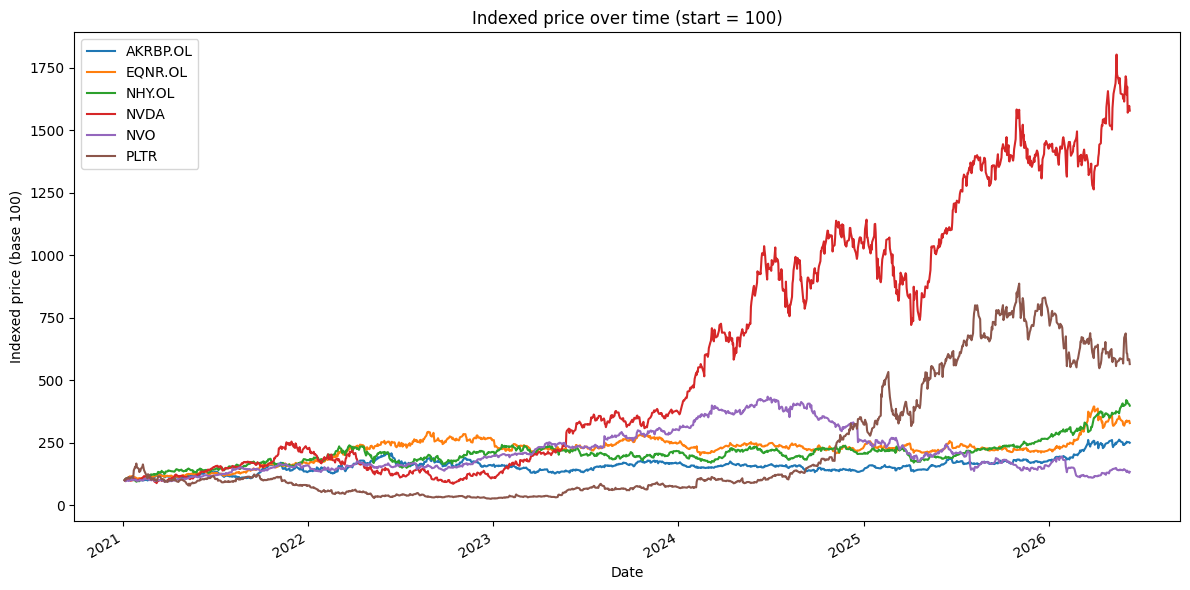

In [ ]:
plt.figure(figsize=(12, 6))

for tic in data.columns:
    series = data[tic].dropna()
    indexed = series / series.iloc[0] * 100
    indexed.plot(label=tic)

plt.title("Indexed price over time (start = 100)")
plt.xlabel("Date")
plt.ylabel("Indexed price (base 100)")
plt.legend()
plt.tight_layout()
plt.show()

### Visualize the target variable
Target variable = will the next days return rise or sink

In [37]:
TICKER = "NVDA"

close = data[TICKER].dropna()
returns = close.pct_change()

# Target: 1 if NEXT day's return is positive, else 0
target = (returns.shift(-1) > 0).astype(int)
target = target.iloc[:-1]   # drop last row (no "next day" exists)

print(target.value_counts())
print("\nProportion:")
print(target.value_counts(normalize=True).round(3))

NVDA
1    730
0    633
Name: count, dtype: int64

Proportion:
NVDA
1    0.536
0    0.464
Name: proportion, dtype: float64


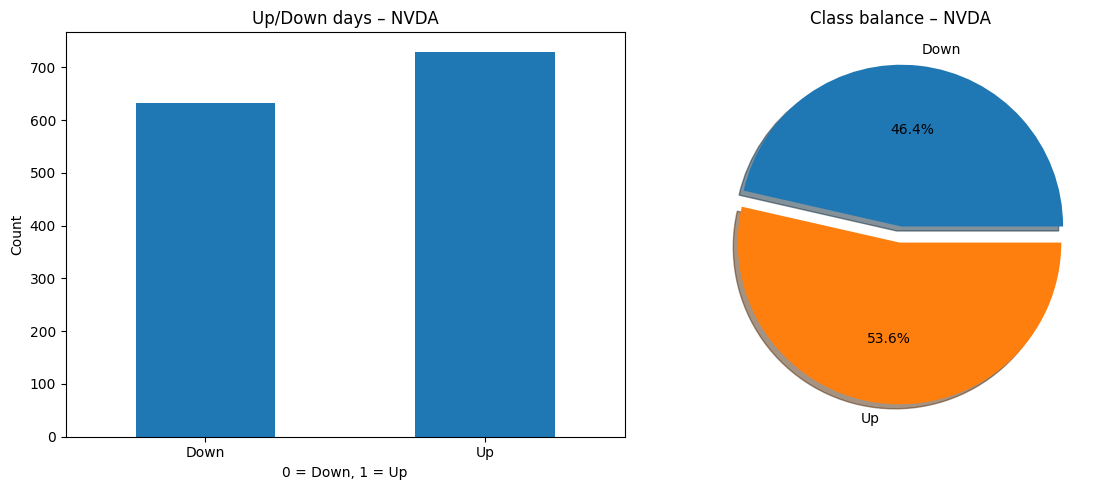

In [38]:
counts = target.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot
counts.plot(kind="bar", ax=axes[0])
axes[0].set_title(f"Up/Down days – {TICKER}")
axes[0].set_xlabel("0 = Down, 1 = Up")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["Down", "Up"], rotation=0)

# Pie chart
axes[1].pie(counts, labels=["Down", "Up"], autopct="%1.1f%%",
            explode=(0.05, 0.05), shadow=True)
axes[1].set_title(f"Class balance – {TICKER}")

plt.tight_layout()
plt.show()

we can see that the distribution is close to 50/50. However, as we commented on the histograms, the market rises a bit more than it sinks.

In [39]:
TICKER = "EQNR.OL"

close = data[TICKER].dropna()
returns = close.pct_change()

# Target: 1 if NEXT day's return is positive, else 0
target = (returns.shift(-1) > 0).astype(int)
target = target.iloc[:-1]   # drop last row (no "next day" exists)

print(target.value_counts())
print("\nProportion:")
print(target.value_counts(normalize=True).round(3))

EQNR.OL
1    722
0    640
Name: count, dtype: int64

Proportion:
EQNR.OL
1    0.53
0    0.47
Name: proportion, dtype: float64


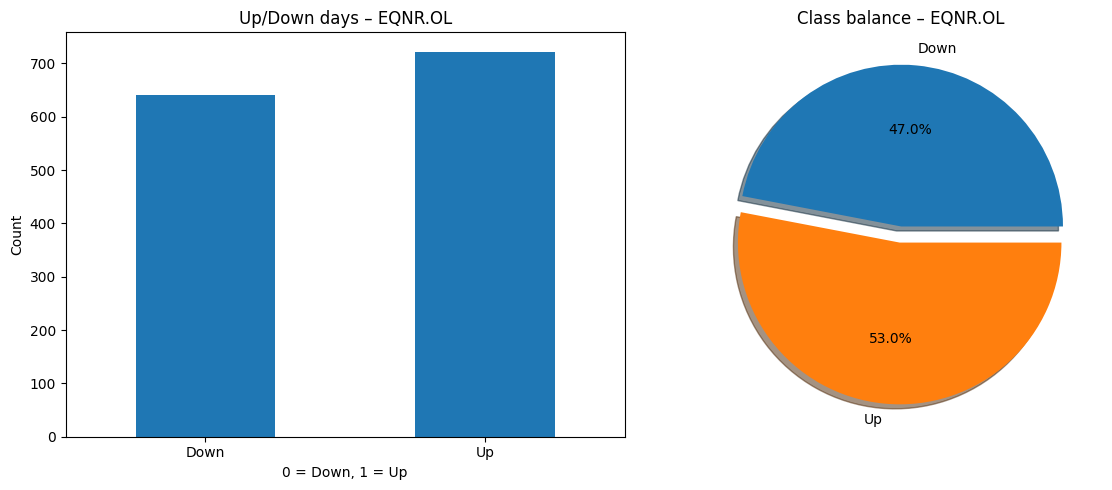

In [40]:
counts = target.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot
counts.plot(kind="bar", ax=axes[0])
axes[0].set_title(f"Up/Down days – {TICKER}")
axes[0].set_xlabel("0 = Down, 1 = Up")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["Down", "Up"], rotation=0)

# Pie chart
axes[1].pie(counts, labels=["Down", "Up"], autopct="%1.1f%%",
            explode=(0.05, 0.05), shadow=True)
axes[1].set_title(f"Class balance – {TICKER}")

plt.tight_layout()
plt.show()

In [41]:
TICKER = "NVO"

close = data[TICKER].dropna()
returns = close.pct_change()

# Target: 1 if NEXT day's return is positive, else 0
target = (returns.shift(-1) > 0).astype(int)
target = target.iloc[:-1]   # drop last row (no "next day" exists)

print(target.value_counts())
print("\nProportion:")
print(target.value_counts(normalize=True).round(3))

NVO
1    704
0    659
Name: count, dtype: int64

Proportion:
NVO
1    0.517
0    0.483
Name: proportion, dtype: float64


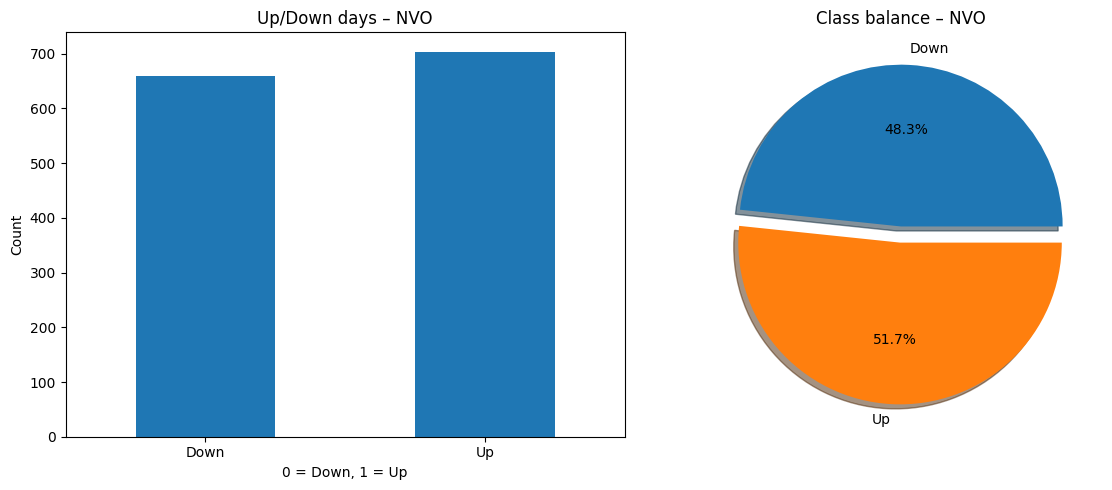

In [42]:
counts = target.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot
counts.plot(kind="bar", ax=axes[0])
axes[0].set_title(f"Up/Down days – {TICKER}")
axes[0].set_xlabel("0 = Down, 1 = Up")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["Down", "Up"], rotation=0)

# Pie chart
axes[1].pie(counts, labels=["Down", "Up"], autopct="%1.1f%%",
            explode=(0.05, 0.05), shadow=True)
axes[1].set_title(f"Class balance – {TICKER}")

plt.tight_layout()
plt.show()

In [43]:


TICKER = "NVDA"

close = data[TICKER].dropna()
ret = close.pct_change()

df = pd.DataFrame(index=close.index)

# Features (all known at end of day t)
df["ret"]         = ret                      # today's return
df["ret_lag1"]    = ret.shift(1)             # yesterday's return
df["ret_lag2"]    = ret.shift(2)             # two days ago
df["roll_mean_5"] = ret.rolling(5).mean()    # avg return, last 5 days
df["roll_mean_20"]= ret.rolling(20).mean()   # avg return, last 20 days
df["roll_vol_5"]  = ret.rolling(5).std()     # volatility, last 5 days
df["roll_vol_20"] = ret.rolling(20).std()    # volatility, last 20 days

# Target: 1 if NEXT day is up, else 0
df["target"] = (ret.shift(-1) > 0).astype(int)

# Feature engineering creates NaNs at the start; target shift creates one at the end
df = df.dropna()

print(df.shape)
df.head()

(1344, 8)


,ret,ret_lag1,ret_lag2,roll_mean_5,roll_mean_20,roll_vol_5,roll_vol_20,target
Date,,,,,,,,
2021-02-02,0.024156,0.019034,-0.004693,0.002059,0.002027,0.025183,0.027649,0
2021-02-03,-0.001936,0.024156,0.019034,0.009375,0.000820,0.012634,0.027246,1
2021-02-04,0.009885,-0.001936,0.024156,0.009289,0.004262,0.012628,0.023370,0
2021-02-05,-0.005361,0.009885,-0.001936,0.009156,0.001102,0.012815,0.019735,1
2021-02-08,0.062376,-0.005361,0.009885,0.017824,0.004473,0.027459,0.023940,0


#### comments on creating features

I´ve created features in different lengths to capture both the short term and long term patterns. this is because the shorter features capture to recent moves, while the longer windows reflect the underlying trend. this will let the model decide which horizon is informative

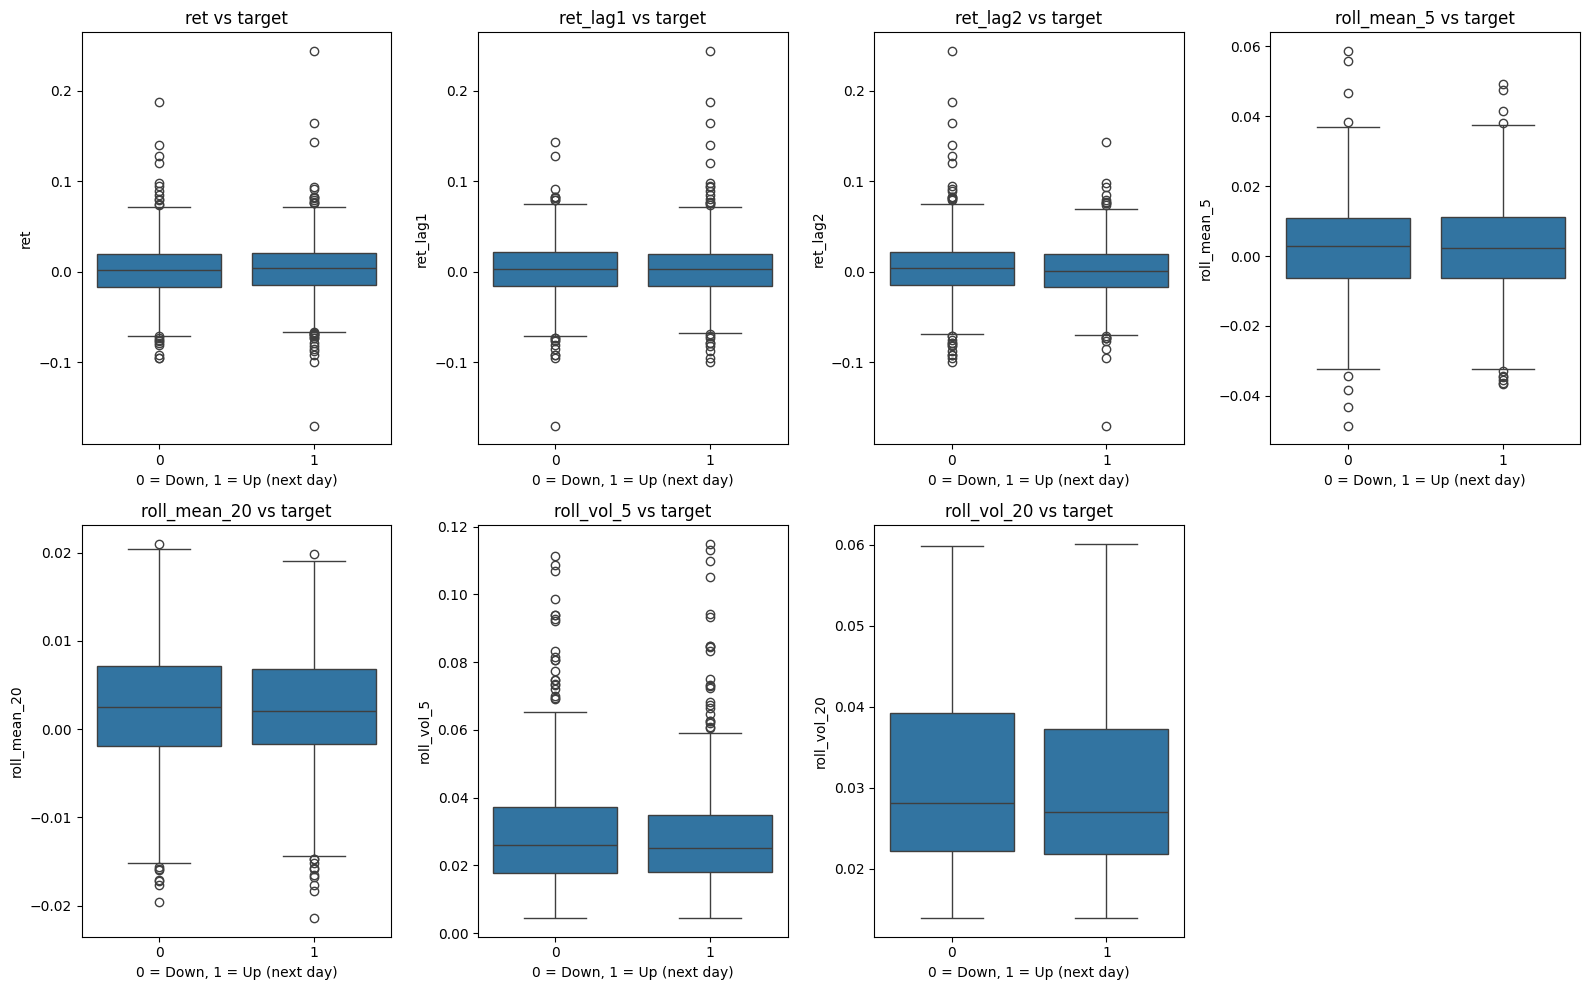

In [44]:
import matplotlib.pyplot as plt
from seaborn import boxplot

features = ["ret", "ret_lag1", "ret_lag2",
            "roll_mean_5", "roll_mean_20", "roll_vol_5", "roll_vol_20"]

plt.figure(figsize=(16, 10))
for i, col in enumerate(features, 1):
    plt.subplot(2, 4, i)
    boxplot(x="target", y=col, data=df)
    plt.title(f"{col} vs target")
    plt.xlabel("0 = Down, 1 = Up (next day)")
plt.tight_layout()
plt.show()

for every feature, the distributions for up and down days are nearly identical, same median, spread and range. the only small difference in down and up days are the volatility features, but the effect is small.
based on the boxplot, we must be prepared that any model will be extracting a very weak signal, and beating the baseline will be difficult

# Correlations with the Target Value

In [46]:
corr = df.corr(numeric_only=True)["target"].sort_values(ascending= False)
print(corr)

target          1.000000
ret_lag1        0.018825
ret             0.007005
roll_mean_5    -0.027734
roll_mean_20   -0.028964
roll_vol_20    -0.038163
roll_vol_5     -0.047139
ret_lag2       -0.051663
Name: target, dtype: float64


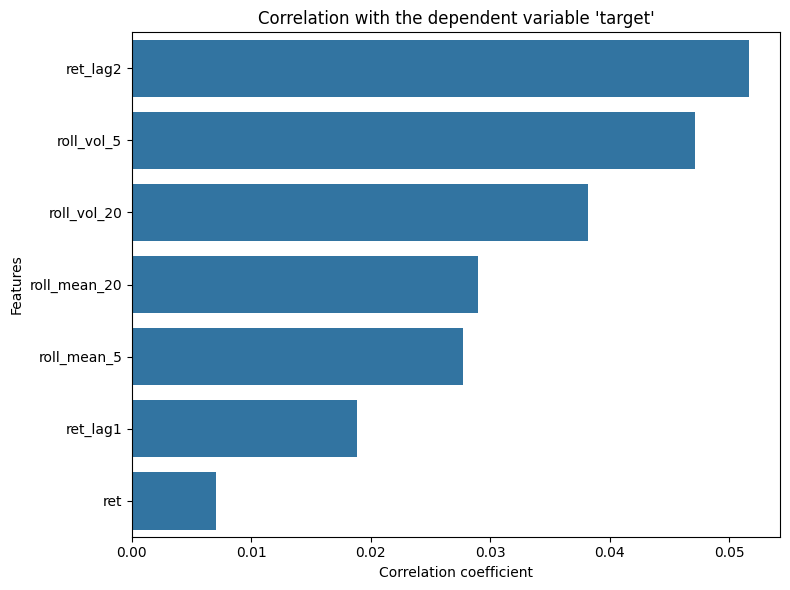

In [47]:

corr_abs = df.corr(numeric_only=True).abs()["target"].sort_values(ascending=False)
corr_abs = corr_abs.drop("target")

plt.figure(figsize=(8, 6))
barplot(x=corr_abs.values, y=corr_abs.index)
plt.title("Correlation with the dependent variable 'target'")
plt.xlabel("Correlation coefficient")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

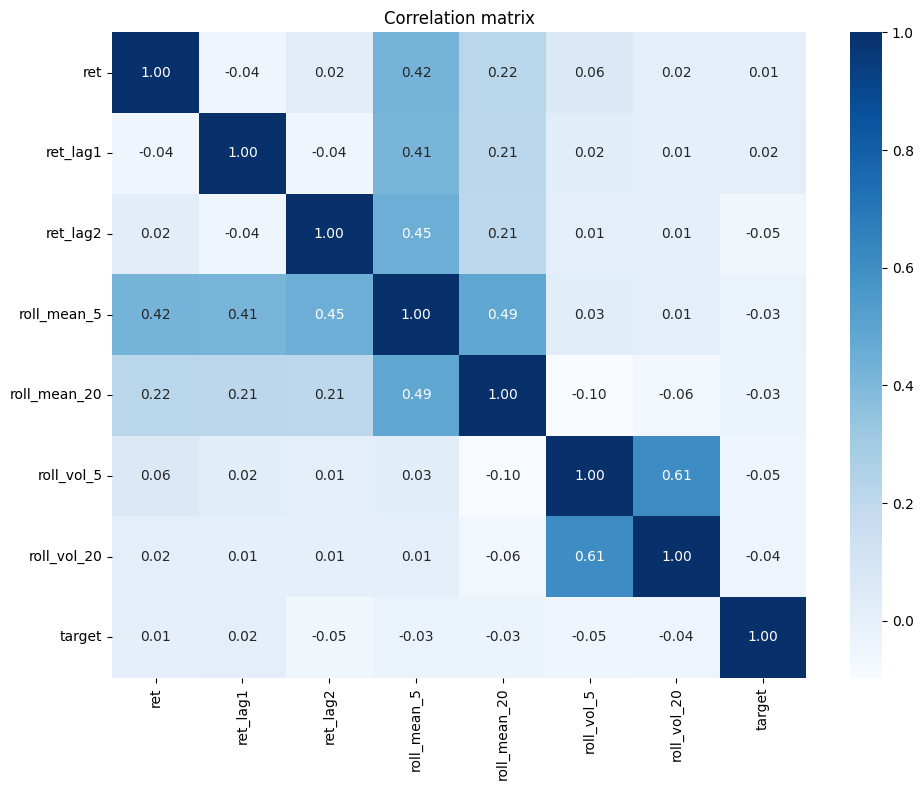

In [48]:

cm = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
heatmap(cm, annot=True, fmt=".2f", cmap="Blues")
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

all features show extreme weak correlation with the target, where absolute correlation is below 0,05. this quantifies the weak predictability of the next-day direction.

the correlation between the features are strongly correlated with each other. this is due to multicollinearity, and must be aknowledged when intepreting the logistic-regression coefficients

In [49]:
TICKER = "AKRBP.OL"

close = data[TICKER].dropna()
ret = close.pct_change()

df = pd.DataFrame(index=close.index)

# Features (all known at end of day t)
df["ret"]         = ret                      # today's return
df["ret_lag1"]    = ret.shift(1)             # yesterday's return
df["ret_lag2"]    = ret.shift(2)             # two days ago
df["roll_mean_5"] = ret.rolling(5).mean()    # avg return, last 5 days
df["roll_mean_20"]= ret.rolling(20).mean()   # avg return, last 20 days
df["roll_vol_5"]  = ret.rolling(5).std()     # volatility, last 5 days
df["roll_vol_20"] = ret.rolling(20).std()    # volatility, last 20 days

# Target: 1 if NEXT day is up, else 0
df["target"] = (ret.shift(-1) > 0).astype(int)

# Feature engineering creates NaNs at the start; target shift creates one at the end
df = df.dropna()

print(df.shape)
df.head()

(1343, 8)


,ret,ret_lag1,ret_lag2,roll_mean_5,roll_mean_20,roll_vol_5,roll_vol_20,target
Date,,,,,,,,
2021-02-01,-0.001400,0.002338,0.001875,-0.004907,0.000021,0.019500,0.023201,1
2021-02-02,0.043458,-0.001400,0.002338,0.001506,0.001264,0.029107,0.024855,1
2021-02-03,0.012987,0.043458,-0.001400,0.011852,-0.000164,0.018479,0.023183,0
2021-02-04,-0.023873,0.012987,0.043458,0.006702,-0.001840,0.024546,0.023643,0
2021-02-05,-0.016304,-0.023873,0.012987,0.002974,-0.002981,0.026696,0.023769,0


In [50]:
corr = df.corr(numeric_only=True)["target"].sort_values(ascending= False)
print(corr)

target          1.000000
roll_vol_5      0.077713
roll_vol_20     0.073517
ret             0.008026
ret_lag2        0.004175
roll_mean_20   -0.020300
roll_mean_5    -0.021159
ret_lag1       -0.067740
Name: target, dtype: float64


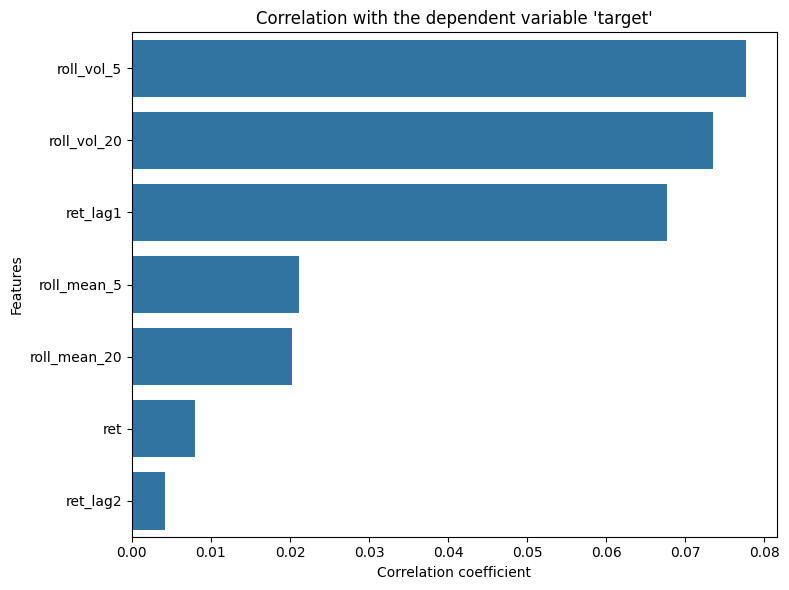

In [51]:
corr_abs = df.corr(numeric_only=True).abs()["target"].sort_values(ascending=False)
corr_abs = corr_abs.drop("target")

plt.figure(figsize=(8, 6))
barplot(x=corr_abs.values, y=corr_abs.index)
plt.title("Correlation with the dependent variable 'target'")
plt.xlabel("Correlation coefficient")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [52]:
TICKER = "PLTR"

close = data[TICKER].dropna()
ret = close.pct_change()

df = pd.DataFrame(index=close.index)

# Features (all known at end of day t)
df["ret"]         = ret                      # today's return
df["ret_lag1"]    = ret.shift(1)             # yesterday's return
df["ret_lag2"]    = ret.shift(2)             # two days ago
df["roll_mean_5"] = ret.rolling(5).mean()    # avg return, last 5 days
df["roll_mean_20"]= ret.rolling(20).mean()   # avg return, last 20 days
df["roll_vol_5"]  = ret.rolling(5).std()     # volatility, last 5 days
df["roll_vol_20"] = ret.rolling(20).std()    # volatility, last 20 days

# Target: 1 if NEXT day is up, else 0
df["target"] = (ret.shift(-1) > 0).astype(int)

# Feature engineering creates NaNs at the start; target shift creates one at the end
df = df.dropna()

print(df.shape)
df.head()

(1344, 8)


,ret,ret_lag1,ret_lag2,roll_mean_5,roll_mean_20,roll_vol_5,roll_vol_20,target
Date,,,,,,,,
2021-02-02,-0.086572,-0.034679,-0.013460,-0.023545,0.016850,0.077418,0.076768,1
2021-02-03,0.023856,-0.086572,-0.034679,-0.039299,0.015411,0.047592,0.076331,1
2021-02-04,0.009131,0.023856,-0.086572,-0.020345,0.018022,0.043190,0.075108,1
2021-02-05,0.062402,0.009131,0.023856,-0.005172,0.018041,0.057250,0.075119,1
2021-02-08,0.058737,0.062402,0.009131,0.013511,0.020578,0.060371,0.075618,1


In [53]:
corr = df.corr(numeric_only=True)["target"].sort_values(ascending= False)
print(corr)

target          1.000000
ret             0.033077
ret_lag1        0.014309
roll_vol_20    -0.008799
ret_lag2       -0.014877
roll_mean_20   -0.016750
roll_mean_5    -0.021637
roll_vol_5     -0.022689
Name: target, dtype: float64


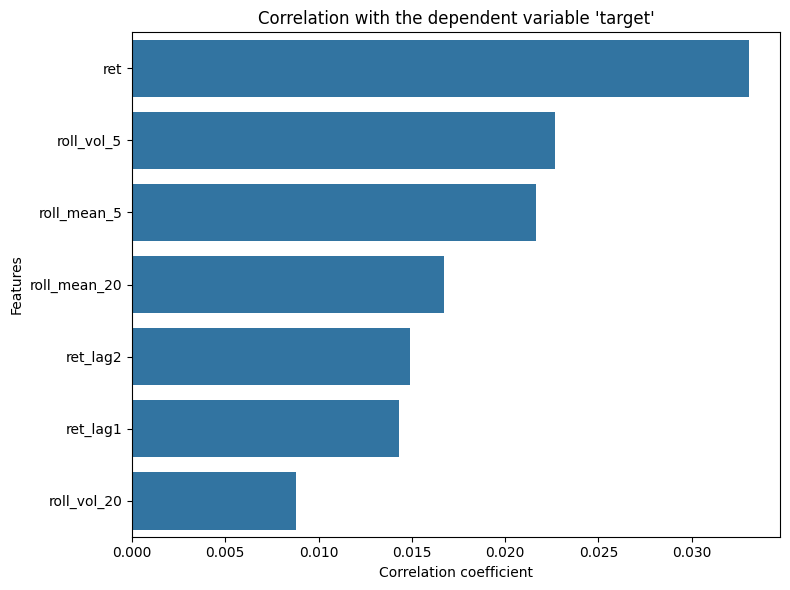

In [54]:
corr_abs = df.corr(numeric_only=True).abs()["target"].sort_values(ascending=False)
corr_abs = corr_abs.drop("target")

plt.figure(figsize=(8, 6))
barplot(x=corr_abs.values, y=corr_abs.index)
plt.title("Correlation with the dependent variable 'target'")
plt.xlabel("Correlation coefficient")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## Summarized table with all six stocks

In [57]:


rows = []
for ticker in data.columns:
    ret = data[ticker].dropna().pct_change().dropna()
    up_share = (ret.shift(-1) > 0).iloc[:-1].mean()   # share of up-days
    rows.append({
        "Ticker": ticker,
        "Mean": round(ret.mean(), 5),
        "Min": round(ret.min(), 4),
        "Max": round(ret.max(), 4),
        "Std (volatility)": round(ret.std(), 4),
        "Skewness": round(ret.skew(), 3),
        "Excess kurtosis": round(ret.kurt(), 3),
        "Up-day share": round(up_share, 3),
    })

eda_summary = pd.DataFrame(rows).sort_values("Std (volatility)")
eda_summary

,Ticker,Mean,Min,Max,Std (volatility),Skewness,Excess kurtosis,Up-day share
1,EQNR.OL,0.00108,-0.1212,0.1103,0.0202,-0.163,2.828,0.530
0,AKRBP.OL,0.00091,-0.1065,0.0836,0.0217,-0.185,1.864,0.530
2,NHY.OL,0.00126,-0.0943,0.1418,0.0223,0.186,2.032,0.514
4,NVO,0.00049,-0.2183,0.1723,0.0235,-1.029,13.905,0.517
3,NVDA,0.00254,-0.1697,0.2437,0.0323,0.506,4.524,0.535
5,PLTR,0.00214,-0.2131,0.3080,0.0422,0.903,6.484,0.509


# Modelling

## Linear Regression

In [61]:
TICKER = "NVDA"

close = data[TICKER].dropna()
ret = close.pct_change()

dfr = pd.DataFrame(index=close.index)
dfr["ret_lag1"]     = ret.shift(1)
dfr["ret_lag2"]     = ret.shift(2)
dfr["roll_mean_5"]  = ret.rolling(5).mean()
dfr["roll_mean_20"] = ret.rolling(20).mean()
dfr["roll_vol_5"]   = ret.rolling(5).std()
dfr["roll_vol_20"]  = ret.rolling(20).std()

# Continuous target: NEXT day's return (the magnitude, not just direction)
dfr["target_ret"] = ret.shift(-1)

dfr = dfr.dropna()

FEATURES_REG = ["ret_lag1", "ret_lag2", "roll_mean_5", "roll_mean_20", "roll_vol_5", "roll_vol_20"]

cut = int(len(dfr) * 0.8)
train, test = dfr.iloc[:cut], dfr.iloc[cut:]
Xtr, ytr = train[FEATURES_REG], train["target_ret"]
Xte, yte = test[FEATURES_REG], test["target_ret"]


lin = LinearRegression()
lin.fit(Xtr, ytr)
pred = lin.predict(Xte)

print("R²:  ", round(r2_score(yte, pred), 4))
print("MAE: ", round(mean_absolute_error(yte, pred), 5))
print("RMSE:", round(np.sqrt(mean_squared_error(yte, pred)), 5))

# Coefficients — which features the model leaned on
coef = pd.DataFrame({"feature": FEATURES_REG, "coef": lin.coef_})
print("\nCoefficients:")
print(coef.to_string(index=False))

R²:   0.0043
MAE:  0.01669
RMSE: 0.02167

Coefficients:
     feature      coef
    ret_lag1  0.029593
    ret_lag2 -0.041579
 roll_mean_5 -0.075934
roll_mean_20  0.069347
  roll_vol_5 -0.100501
 roll_vol_20 -0.019863


stock price data is a timeseries. the rows in days are not independant, but in an important order. when using the train_test_split from sklearn, the dataset is set to be independant rows, which is not the case here.


## Price Plot

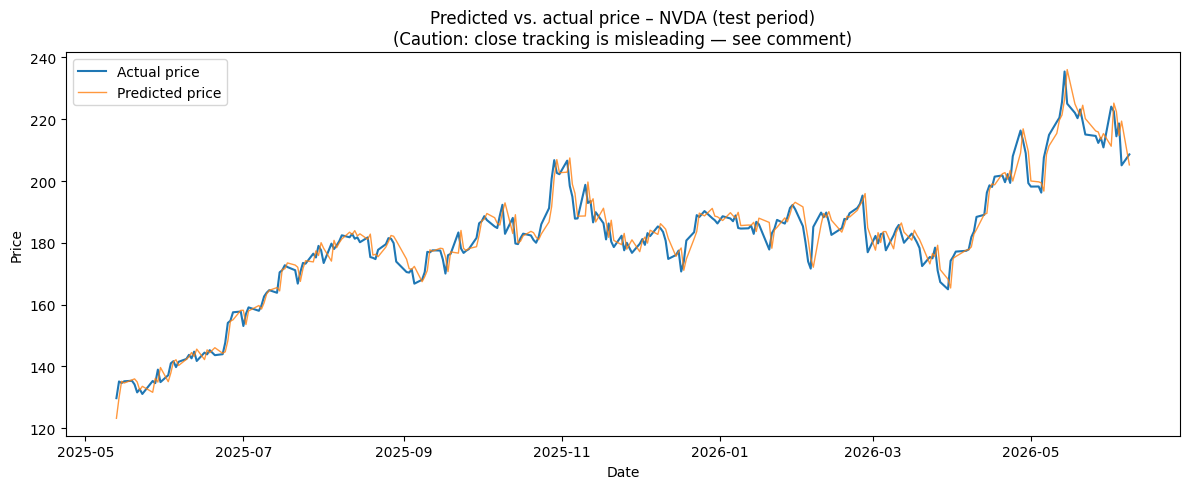

In [62]:


# Actual close prices over the test period
actual_price = close.loc[test.index]

# Reconstruct predicted price: yesterday's actual price × (1 + predicted return)
# We use the actual previous-day price as the base each day
prev_price = close.shift(1).loc[test.index]
predicted_price = prev_price * (1 + pred)

plt.figure(figsize=(12, 5))
plt.plot(actual_price.index, actual_price, label="Actual price", linewidth=1.5)
plt.plot(predicted_price.index, predicted_price, label="Predicted price", linewidth=1.0, alpha=0.8)
plt.title(f"Predicted vs. actual price – {TICKER} (test period)\n(Caution: close tracking is misleading — see comment)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

In [63]:
# Naive price prediction: tomorrow = today (no model at all)
naive_price = prev_price

mae_model = mean_absolute_error(actual_price, predicted_price)
mae_naive = mean_absolute_error(actual_price, naive_price)

print(f"MAE, model-based price:  {mae_model:.3f}")
print(f"MAE, naive 'same as yesterday': {mae_naive:.3f}")

MAE, model-based price:  3.142
MAE, naive 'same as yesterday': 3.096


the predicted and actual price curves track each other almost perfectly. this makes it look like an almost perfect model, but it is misleading. Because each prediction is anchored to the previous day's actual price, and prices change little day-to-day, the result is nearly indistinguishable from a naive "tomorrow = today" forecast. The MAE comparison confirms this: the model's price error is essentially equal to the naive baseline's. This is exactly why we evaluate in return space (R² ≈ 0) rather than price space, the price chart flatters a model that has learned almost nothing.

# Logistic regression



In [64]:

TICKER = "NVDA"

close = data[TICKER].dropna()
ret = close.pct_change()

dfc = pd.DataFrame(index=close.index)
dfc["ret"]          = ret
dfc["ret_lag1"]     = ret.shift(1)
dfc["ret_lag2"]     = ret.shift(2)
dfc["roll_mean_5"]  = ret.rolling(5).mean()
dfc["roll_mean_20"] = ret.rolling(20).mean()
dfc["roll_vol_5"]   = ret.rolling(5).std()
dfc["roll_vol_20"]  = ret.rolling(20).std()
dfc["target"]       = (ret.shift(-1) > 0).astype(int)   # 1 = up tomorrow
dfc = dfc.dropna()

FEATURES = ["ret", "ret_lag1", "ret_lag2", "roll_mean_5", "roll_mean_20", "roll_vol_5", "roll_vol_20"]

# Chronological split — past trains, future tests
cut = int(len(dfc) * 0.8)
train, test = dfc.iloc[:cut], dfc.iloc[cut:]
Xtr, ytr = train[FEATURES], train["target"]
Xte, yte = test[FEATURES], test["target"]

# Baseline: always predict the majority class from training
majority = ytr.mode()[0]
from sklearn.metrics import accuracy_score
base_acc = accuracy_score(yte, np.full(len(yte), majority))
print(f"Majority class in training: {majority}  (1 = up, 0 = down)")
print(f"Baseline accuracy (always predict {majority}): {base_acc:.3f}")

Majority class in training: 1  (1 = up, 0 = down)
Baseline accuracy (always predict 1): 0.535


In [67]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score


logreg = Pipeline([
    ("scaler", MinMaxScaler()),
    ("model", LogisticRegression(max_iter=1000))
])
logreg.fit(Xtr, ytr)

pred  = logreg.predict(Xte)
proba = logreg.predict_proba(Xte)[:, 1]

print(f"Accuracy: {accuracy_score(yte, pred):.3f}   (baseline: {base_acc:.3f})")
print(f"ROC-AUC:  {roc_auc_score(yte, proba):.3f}   (0.50 = random)")
print("\nConfusion matrix:")
print(confusion_matrix(yte, pred))
print("\nClassification report:")
print(classification_report(yte, pred, target_names=["Down", "Up"]))

Accuracy: 0.524   (baseline: 0.535)
ROC-AUC:  0.533   (0.50 = random)

Confusion matrix:
[[  1 124]
 [  4 140]]

Classification report:
              precision    recall  f1-score   support

        Down       0.20      0.01      0.02       125
          Up       0.53      0.97      0.69       144

    accuracy                           0.52       269
   macro avg       0.37      0.49      0.35       269
weighted avg       0.38      0.52      0.37       269



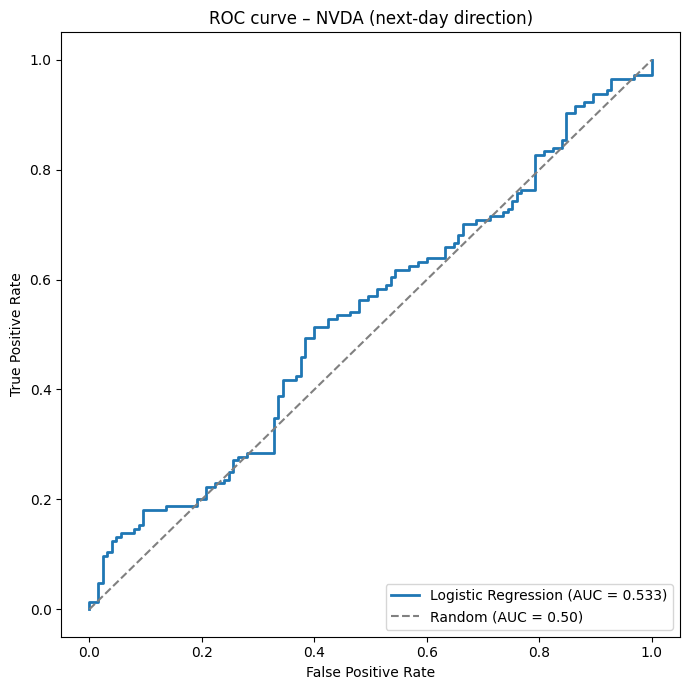

In [68]:
auc = roc_auc_score(yte, proba)
fpr, tpr, thresholds = roc_curve(yte, proba)

plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, linewidth=2, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random (AUC = 0.50)")
plt.title(f"ROC curve – {TICKER} (next-day direction)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Logistic regression achieves accuracy near the baseline and an AUC close to 0.50, indicating it barely distinguishes up- from down-days. The confusion matrix shows the model predicts the majority class ("Up") for most days, effectively reproducing the baseline. This is consistent with the weak signal seen throughout the EDA: linear separation of next-day direction from past returns is not achievable here.


The ROC curve hugs the diagonal (AUC ≈ 0.50), showing the model barely separates up- from down-days

## Naive Bayes

In [69]:

nb = Pipeline([
    ("scaler", MinMaxScaler()),
    ("model", GaussianNB())
])
nb.fit(Xtr, ytr)

pred_nb  = nb.predict(Xte)
proba_nb = nb.predict_proba(Xte)[:, 1]

print(f"Accuracy: {accuracy_score(yte, pred_nb):.3f}   (baseline: {base_acc:.3f})")
print(f"ROC-AUC:  {roc_auc_score(yte, proba_nb):.3f}   (0.50 = random)")
print("\nConfusion matrix:")
print(confusion_matrix(yte, pred_nb))
print("\nClassification report:")
print(classification_report(yte, pred_nb, target_names=["Down", "Up"]))

Accuracy: 0.528   (baseline: 0.535)
ROC-AUC:  0.529   (0.50 = random)

Confusion matrix:
[[  4 121]
 [  6 138]]

Classification report:
              precision    recall  f1-score   support

        Down       0.40      0.03      0.06       125
          Up       0.53      0.96      0.68       144

    accuracy                           0.53       269
   macro avg       0.47      0.50      0.37       269
weighted avg       0.47      0.53      0.39       269



Naive Bayes performs similarly to logistic regression — accuracy near baseline, AUC near 0.50. Note that its independence assumption is violated here, since several features (e.g. the rolling-volatility pair) are strongly correlated, as seen in the correlation heatmap. Unlike logistic regression, it distributes predictions less one-sidedly across the two classes, but without a meaningful gain in separating power.

## Decision Tree (pruning)

In [70]:
# Pruned tree: limit depth and require a minimum leaf size to avoid overfitting noise
tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=20,
    random_state=0
)
tree.fit(Xtr, ytr)

pred_tree  = tree.predict(Xte)
proba_tree = tree.predict_proba(Xte)[:, 1]

print(f"Accuracy: {accuracy_score(yte, pred_tree):.3f}   (baseline: {base_acc:.3f})")
print(f"ROC-AUC:  {roc_auc_score(yte, proba_tree):.3f}   (0.50 = random)")
print("\nConfusion matrix:")
print(confusion_matrix(yte, pred_tree))
print("\nClassification report:")
print(classification_report(yte, pred_tree, target_names=["Down", "Up"]))

Accuracy: 0.509   (baseline: 0.535)
ROC-AUC:  0.514   (0.50 = random)

Confusion matrix:
[[ 25 100]
 [ 32 112]]

Classification report:
              precision    recall  f1-score   support

        Down       0.44      0.20      0.27       125
          Up       0.53      0.78      0.63       144

    accuracy                           0.51       269
   macro avg       0.48      0.49      0.45       269
weighted avg       0.49      0.51      0.46       269



In [72]:
#Feature importance, which features the tree leaned on
importances = pd.DataFrame({
    "feature": FEATURES,
    "importance": tree.feature_importances_
}).sort_values("importance", ascending=False)

print(importances.to_string(index=False))

     feature  importance
         ret    0.229439
    ret_lag2    0.185564
 roll_vol_20    0.162877
 roll_mean_5    0.142310
  roll_vol_5    0.141013
roll_mean_20    0.138797
    ret_lag1    0.000000


The pruned decision tree performs at or below the baseline, with AUC near 0.50, likely the weakest of the three models. Flexible models like trees are prone to fitting noise when no real signal exists, which explains the drop. Feature importances should not be over-interpreted: they reflect where the tree happened to split, not genuine predictive drivers, since the model does not outperform the baseline.

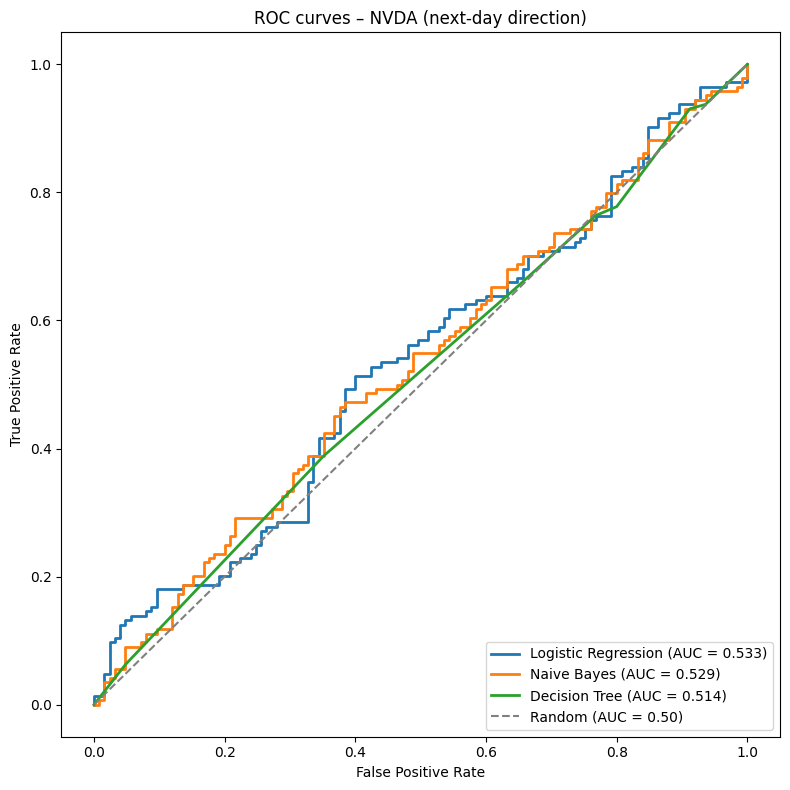

In [73]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 8))

# One curve per model
for label, p in [
    ("Logistic Regression", proba),
    ("Naive Bayes",         proba_nb),
    ("Decision Tree",       proba_tree),
]:
    fpr, tpr, _ = roc_curve(yte, p)
    auc = roc_auc_score(yte, p)
    plt.plot(fpr, tpr, linewidth=2, label=f"{label} (AUC = {auc:.3f})")

# Random baseline
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random (AUC = 0.50)")

plt.title(f"ROC curves – {TICKER} (next-day direction)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

All three models — logistic regression, Naive Bayes, and a pruned decision tree, produce ROC curves that hug the diagonal (AUC ≈ 0.50), crossing each other without any rising clearly above random. That three fundamentally different model types converge on the same near-random performance is strong evidence that the limitation lies in the data, not the choice of model: next-day direction simply is not predictable from historical price features.

# All models summarized, based on the 6 stocks

In [74]:

FEATURES = ["ret", "ret_lag1", "ret_lag2",
            "roll_mean_5", "roll_mean_20", "roll_vol_5", "roll_vol_20"]

def build_features(close):
    ret = close.pct_change()
    df = pd.DataFrame(index=close.index)
    df["ret"]          = ret
    df["ret_lag1"]     = ret.shift(1)
    df["ret_lag2"]     = ret.shift(2)
    df["roll_mean_5"]  = ret.rolling(5).mean()
    df["roll_mean_20"] = ret.rolling(20).mean()
    df["roll_vol_5"]   = ret.rolling(5).std()
    df["roll_vol_20"]  = ret.rolling(20).std()
    df["target"]       = (ret.shift(-1) > 0).astype(int)
    return df.dropna()

results = []
for ticker in data.columns:
    df = build_features(data[ticker].dropna())

    cut = int(len(df) * 0.8)
    train, test = df.iloc[:cut], df.iloc[cut:]
    Xtr, ytr = train[FEATURES], train["target"]
    Xte, yte = test[FEATURES], test["target"]

    # Baseline: always predict the training majority class
    majority = ytr.mode()[0]
    base_acc = accuracy_score(yte, np.full(len(yte), majority))

    models = {
        "LogReg":       Pipeline([("scaler", MinMaxScaler()), ("m", LogisticRegression(max_iter=1000))]),
        "NaiveBayes":   Pipeline([("scaler", MinMaxScaler()), ("m", GaussianNB())]),
        "DecisionTree": DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, random_state=0),
    }

    row = {"Ticker": ticker, "n_test": len(yte), "Baseline": round(base_acc, 3)}
    for name, mdl in models.items():
        mdl.fit(Xtr, ytr)
        pred  = mdl.predict(Xte)
        proba = mdl.predict_proba(Xte)[:, 1]
        row[f"{name}_acc"] = round(accuracy_score(yte, pred), 3)
        row[f"{name}_auc"] = round(roc_auc_score(yte, proba), 3)
    results.append(row)

results = pd.DataFrame(results)
results

,Ticker,n_test,Baseline,LogReg_acc,LogReg_auc,NaiveBayes_acc,NaiveBayes_auc,DecisionTree_acc,DecisionTree_auc
0,AKRBP.OL,269,0.561,0.520,0.528,0.528,0.564,0.532,0.522
1,EQNR.OL,269,0.550,0.524,0.543,0.554,0.564,0.502,0.479
2,NHY.OL,269,0.565,0.546,0.583,0.446,0.536,0.561,0.519
3,NVDA,269,0.535,0.524,0.533,0.528,0.529,0.509,0.514
4,NVO,269,0.480,0.480,0.470,0.472,0.484,0.502,0.494
5,PLTR,269,0.539,0.513,0.488,0.528,0.507,0.509,0.469


In [75]:
summary = results.copy()
for name in ["LogReg", "NaiveBayes", "DecisionTree"]:
    summary[f"{name}_beats"] = summary[f"{name}_acc"] > summary["Baseline"]

summary

,Ticker,n_test,Baseline,LogReg_acc,LogReg_auc,NaiveBayes_acc,NaiveBayes_auc,DecisionTree_acc,DecisionTree_auc,LogReg_beats,NaiveBayes_beats,DecisionTree_beats
0,AKRBP.OL,269,0.561,0.520,0.528,0.528,0.564,0.532,0.522,False,False,False
1,EQNR.OL,269,0.550,0.524,0.543,0.554,0.564,0.502,0.479,False,True,False
2,NHY.OL,269,0.565,0.546,0.583,0.446,0.536,0.561,0.519,False,False,False
3,NVDA,269,0.535,0.524,0.533,0.528,0.529,0.509,0.514,False,False,False
4,NVO,269,0.480,0.480,0.470,0.472,0.484,0.502,0.494,False,False,True
5,PLTR,269,0.539,0.513,0.488,0.528,0.507,0.509,0.469,False,False,False


In [76]:
# Bring in volatility from the EDA summary and compare to best AUC per stock
vol = {t: data[t].dropna().pct_change().std() for t in data.columns}

results["volatility"] = results["Ticker"].map(vol).round(4)
results["best_auc"]   = results[["LogReg_auc", "NaiveBayes_auc", "DecisionTree_auc"]].max(axis=1)

results[["Ticker", "volatility", "Baseline", "best_auc"]].sort_values("volatility")

,Ticker,volatility,Baseline,best_auc
1,EQNR.OL,0.0202,0.550,0.564
0,AKRBP.OL,0.0217,0.561,0.564
2,NHY.OL,0.0223,0.565,0.583
4,NVO,0.0235,0.480,0.494
3,NVDA,0.0323,0.535,0.533
5,PLTR,0.0422,0.539,0.507


Across all six stocks and three model types, accuracy clusters around the naive baseline and AUC around 0.50. No model consistently beats its baseline, and the stocks where one does are within the noise expected from ~275 test days (random models would beat the baseline ~half the time by chance). Comparing best AUC against volatility shows no systematic relationship, unpredictability is universal across the sample, not confined to the most volatile names. This is the project's central result: simple supervised learning on historical price features does not reliably forecast next-day direction, consistent with weak-form market efficiency. The same pipeline that separated classes well in the churn case fails here, not because the method is wrong, but because the signal is absent.

## Conclusion

The goal was to see if next-day stock movements can be predicted from past price
data. I looked at six stocks and tried two things: linear regression on next-day
returns, and classification of next-day direction (up/down).

The EDA already showed a weak signal. All features had very low correlation with
the target (|r| < 0.05), and the boxplots for up- and down-days looked almost
identical.

The models confirmed this. Linear regression gave an R² near zero, so the size of
next-day returns can't really be predicted. For direction, logistic regression,
Naive Bayes and the decision tree all stayed close to the baseline, with AUC
around 0.50. None of them clearly beat the baseline across the six stocks.

So the main result is that these simple models can't reliably predict next-day
direction from price history alone. This fits the idea of market efficiency - if
it was easy, the pattern would already be gone. Interesting to note that the same
models worked well on the churn data earlier, so the issue is the data, not the
method.

Possible improvements: use other features than just price (for example
fundamentals), test longer horizons, or use walk-forward validation instead of a
single split.

# Relative Valuation With Trading Multiples

In [ ]:

import yfinance as yf

t = yf.Ticker("EQNR.OL")
print(t.quarterly_financials)     # kvartalsvise resultattall
print(t.balance_sheet)            # balanse
print(t.info.get("trailingPE"))   # ferdig P/E-nøkkeltall

                                                      2026-03-31  \
Tax Effect Of Unusual Items                         4.092000e+08   
Tax Rate For Calcs                                  4.000000e-01   
Normalized EBITDA                                   1.168400e+10   
Total Unusual Items                                 1.023000e+09   
Total Unusual Items Excluding Goodwill              1.023000e+09   
Net Income From Continuing Operation Net Minori...  3.106000e+09   
Reconciled Depreciation                             2.530000e+09   
Reconciled Cost Of Revenue                          1.548400e+10   
EBITDA                                              1.270700e+10   
EBIT                                                1.017700e+10   
Net Interest Income                                -6.300000e+07   
Interest Expense                                    4.330000e+08   
Interest Income                                     3.700000e+08   
Normalized Income                               